In [36]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

In [37]:
DATA_PATH = "HBSC_data/HBSC2018OAed1.1.csv"
AGE_MIN = 13.0
AGE_MAX = 16.5
TARGET = "distress_score_100"
N_OOS_RUNS = 5
TEST_SIZE = 0.20
RANDOM_SEEDS = [11, 23, 37, 49, 61]
MIN_STRATUM_COUNT = 30

In [38]:
def cronbach_alpha(df_items):
    items = df_items.dropna().copy()
    k = items.shape[1]
    if k <= 1:
        return np.nan
    item_variances = items.var(axis=0, ddof=1)
    total_variance = items.sum(axis=1).var(ddof=1)
    if total_variance == 0:
        return np.nan
    return (k / (k - 1)) * (1 - item_variances.sum() / total_variance)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def print_header(title):
    print("\n" + "=" * len(title))
    print(title)
    print("=" * len(title))

In [39]:
print_header("LOAD DATA")
df = pd.read_csv(DATA_PATH, sep=";", engine="python")
print("Raw dataset shape:", df.shape)

df["age"] = pd.to_numeric(
    df["age"].astype(str).str.replace(",", ".", regex=False),
    errors="coerce"
)
df = df[(df["age"] >= AGE_MIN) & (df["age"] <= AGE_MAX)].copy()
print(f"Filtered dataset shape (age {AGE_MIN}-{AGE_MAX}):", df.shape)


LOAD DATA
Raw dataset shape: (244097, 120)
Filtered dataset shape (age 13.0-16.5): (156603, 120)


In [40]:
print_header("BUILD DISTRESS TARGET")

y_vars = ["feellow", "irritable", "nervous", "lifesat"]
for col in y_vars:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["feellow_rev"]   = 6  - df["feellow"]
df["irritable_rev"] = 6  - df["irritable"]
df["nervous_rev"]   = 6  - df["nervous"]
df["lifesat_rev"]   = 10 - df["lifesat"]

reversed_y_vars = ["feellow_rev", "irritable_rev", "nervous_rev", "lifesat_rev"]

df_y = df.dropna(subset=y_vars).copy()
print("Rows after dropping missing target items:", len(df_y))
print("Percent removed:", round((len(df) - len(df_y)) / len(df) * 100, 2), "%")

alpha_val = cronbach_alpha(df_y[reversed_y_vars])
print("Cronbach's alpha for distress items:", round(alpha_val, 4))

from sklearn.preprocessing import StandardScaler as _SS
_sc = _SS()
z_vars = [v + "_z" for v in reversed_y_vars]
df_y[z_vars] = _sc.fit_transform(df_y[reversed_y_vars])
df_y["distress_score_z"] = df_y[z_vars].mean(axis=1)

t_min = df_y["distress_score_z"].min()
t_max = df_y["distress_score_z"].max()
df_y["distress_score_100"] = (
    (df_y["distress_score_z"] - t_min) / (t_max - t_min)
) * 100

print(df_y["distress_score_100"].describe())


BUILD DISTRESS TARGET
Rows after dropping missing target items: 150867
Percent removed: 3.66 %
Cronbach's alpha for distress items: 0.7366
count    150867.000000
mean         32.551572
std          21.851741
min           0.000000
25%          15.507228
50%          28.447825
75%          47.538604
max         100.000000
Name: distress_score_100, dtype: float64


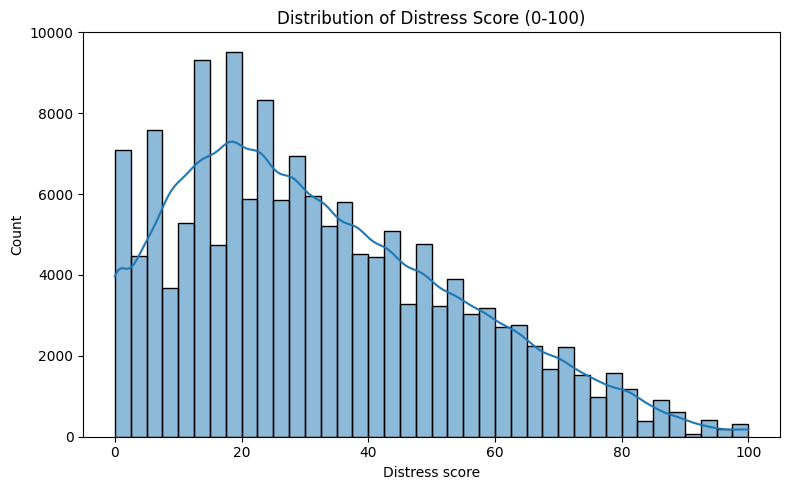

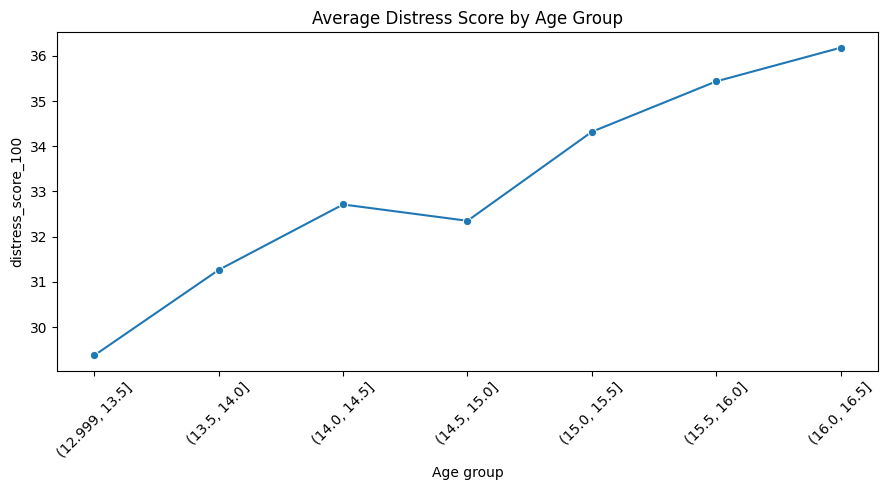

In [41]:
plt.figure(figsize=(8, 5))
sns.histplot(df_y["distress_score_100"], bins=40, kde=True)
plt.title("Distribution of Distress Score (0-100)")
plt.xlabel("Distress score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

df_y["age_bin"] = pd.cut(df_y["age"], bins=np.arange(13, 16.6, 0.5), include_lowest=True)
age_bin_mean = (
    df_y.groupby("age_bin", dropna=False)[TARGET]
    .mean()
    .reset_index()
)
age_bin_mean["age_bin"] = age_bin_mean["age_bin"].astype(str)

plt.figure(figsize=(9, 5))
sns.lineplot(data=age_bin_mean, x="age_bin", y=TARGET, marker="o")
plt.title("Average Distress Score by Age Group")
plt.xlabel("Age group")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [42]:
print_header("BUILD FEATURES")

metadata_cols = {"HBSC", "seqno_int", "cluster", "id1", "id2", "id3", "id4",
                 "weight", "adm", "month", "year"}
target_cols = {"feellow", "irritable", "nervous", "lifesat"}
derived_cols = {"distress_score_100", "distress_score_z",
                "feellow_rev", "irritable_rev", "nervous_rev", "lifesat_rev",
                "feellow_rev_z", "irritable_rev_z", "nervous_rev_z", "lifesat_rev_z",
                "age_bin"}
exclude = metadata_cols | target_cols | derived_cols

feature_cols = [c for c in df_y.columns if c not in exclude]

for col in feature_cols:
    df_y[col] = pd.to_numeric(df_y[col], errors="coerce")

print(f"Total features: {len(feature_cols)}")
for i, c in enumerate(feature_cols, 1):
    print(f"  {i}: {c}")


BUILD FEATURES
Total features: 105
  1: countryno
  2: region
  3: age
  4: agecat
  5: sex
  6: grade
  7: monthbirth
  8: yearbirth
  9: fasfamcar
  10: fasbedroom
  11: fascomputers
  12: fasbathroom
  13: fasdishwash
  14: fasholidays
  15: health
  16: headache
  17: stomachache
  18: backache
  19: sleepdificulty
  20: dizzy
  21: thinkbody
  22: physact60
  23: breakfastwd
  24: breakfastwe
  25: fruits_2
  26: vegetables_2
  27: sweets_2
  28: softdrinks_2
  29: fmeal
  30: toothbr
  31: timeexe
  32: smokltm
  33: smok30d_2
  34: alcltm
  35: alc30d_2
  36: drunkltm
  37: drunk30d
  38: cannabisltm_2
  39: cannabis30d_2
  40: bodyweight
  41: bodyheight
  42: likeschool
  43: schoolpressure
  44: studtogether
  45: studhelpful
  46: studaccept
  47: teacheraccept
  48: teachercare
  49: teachertrust
  50: bulliedothers
  51: beenbullied
  52: cbulliedothers
  53: cbeenbullied
  54: fight12m
  55: injured12m
  56: friendhelp
  57: friendcounton
  58: friendshare
  59: friendta

In [43]:
print_header("DIRECTION AUDIT")
print(f"{'Feature':<30} {'Corr w/ distress':>16}  {'Direction':>10}")
print("-" * 60)

for col in feature_cols:
    valid = df_y[[col, TARGET]].dropna()
    if len(valid) > 100:
        r = valid[col].corr(valid[TARGET])
        direction = "+" if r > 0 else "-"
        print(f"{col:<30} {r:>+16.4f}  {direction}")


DIRECTION AUDIT
Feature                        Corr w/ distress   Direction
------------------------------------------------------------
countryno                               +0.0461  +
age                                     +0.1084  +
agecat                                  +0.0963  +
sex                                     +0.2116  +
grade                                   +0.0983  +
monthbirth                              +0.0067  +
yearbirth                               -0.0727  -
fasfamcar                               -0.0303  -
fasbedroom                              -0.0455  -
fascomputers                            +0.0014  +
fasbathroom                             -0.0149  -
fasdishwash                             -0.0139  -
fasholidays                             -0.0881  -
health                                  +0.3762  +
headache                                -0.4325  -
stomachache                             -0.3909  -
backache                                -0.341

In [44]:
print_header("BUILD WORKING DATASET")

model_cols = list(dict.fromkeys(feature_cols + [TARGET]))
working_df = df_y[model_cols].copy()
working_df = working_df[working_df[TARGET].notna()].copy()

print("Working dataframe shape:", working_df.shape)
print("Features:", len(feature_cols))

working_df["age_band"] = pd.cut(
    working_df["age"],
    bins=[13, 14, 15, 16, 16.5],
    include_lowest=True
).astype(str)
working_df["sex_str"] = working_df["sex"].astype("Int64").astype(str)
working_df["strata"]  = working_df["age_band"] + "__" + working_df["sex_str"]

strata_counts = working_df["strata"].value_counts(dropna=False)
small_strata  = strata_counts[strata_counts < MIN_STRATUM_COUNT].index
working_df.loc[working_df["strata"].isin(small_strata), "strata"] = "other"

print("\nStrata counts:")
print(working_df["strata"].value_counts(dropna=False))

missing_pct = working_df[feature_cols].isnull().mean().sort_values(ascending=False)
print(f"\nMissing data % (top 15):")
print(missing_pct.head(15).to_string())


BUILD WORKING DATASET
Working dataframe shape: (150867, 106)
Features: 105

Strata counts:
strata
(12.999, 14.0]__2    35913
(12.999, 14.0]__1    34569
(15.0, 16.0]__2      31952
(15.0, 16.0]__1      29484
(14.0, 15.0]__2       7186
(14.0, 15.0]__1       6917
(16.0, 16.5]__1       2487
(16.0, 16.5]__2       2359
Name: count, dtype: int64

Missing data % (top 15):
countrybornfa       1.000000
region              1.000000
countryborn         1.000000
countrybornmo       1.000000
MBMI                0.995990
employnotfa         0.920712
contraceptpill      0.902689
agesex              0.902451
contraceptcondom    0.900402
employnotmo         0.821233
hadsex              0.496795
cannabis30d_2       0.436663
cannabisltm_2       0.428119
grade               0.266374
talkstepmo          0.258214



FEATURE CORRELATIONS
         feature  correlation  abs_corr      n
  sleepdificulty    -0.457509  0.457509 147935
        headache    -0.432492  0.432492 150778
           dizzy    -0.423125  0.423125 149929
     stomachache    -0.390895  0.390895 150693
          health     0.376200  0.376200 150148
        backache    -0.341442  0.341442 150561
  schoolpressure     0.314931  0.314931 148625
      talkfather     0.304354  0.304354 142521
         famtalk    -0.301528  0.301528 141210
      studaccept     0.294734  0.294734 141798
      talkmother     0.293306  0.293306 143900
      likeschool     0.278287  0.278287 148797
          famsup    -0.264729  0.264729 141205
    teachertrust     0.255469  0.255469 141498
   teacheraccept     0.254306  0.254306 141924
     studhelpful     0.251761  0.251761 142124
          famdec    -0.229586  0.229586 141119
     teachercare     0.227528  0.227528 141362
     beenbullied     0.225803  0.225803 142082
    studtogether     0.218111  0.21811

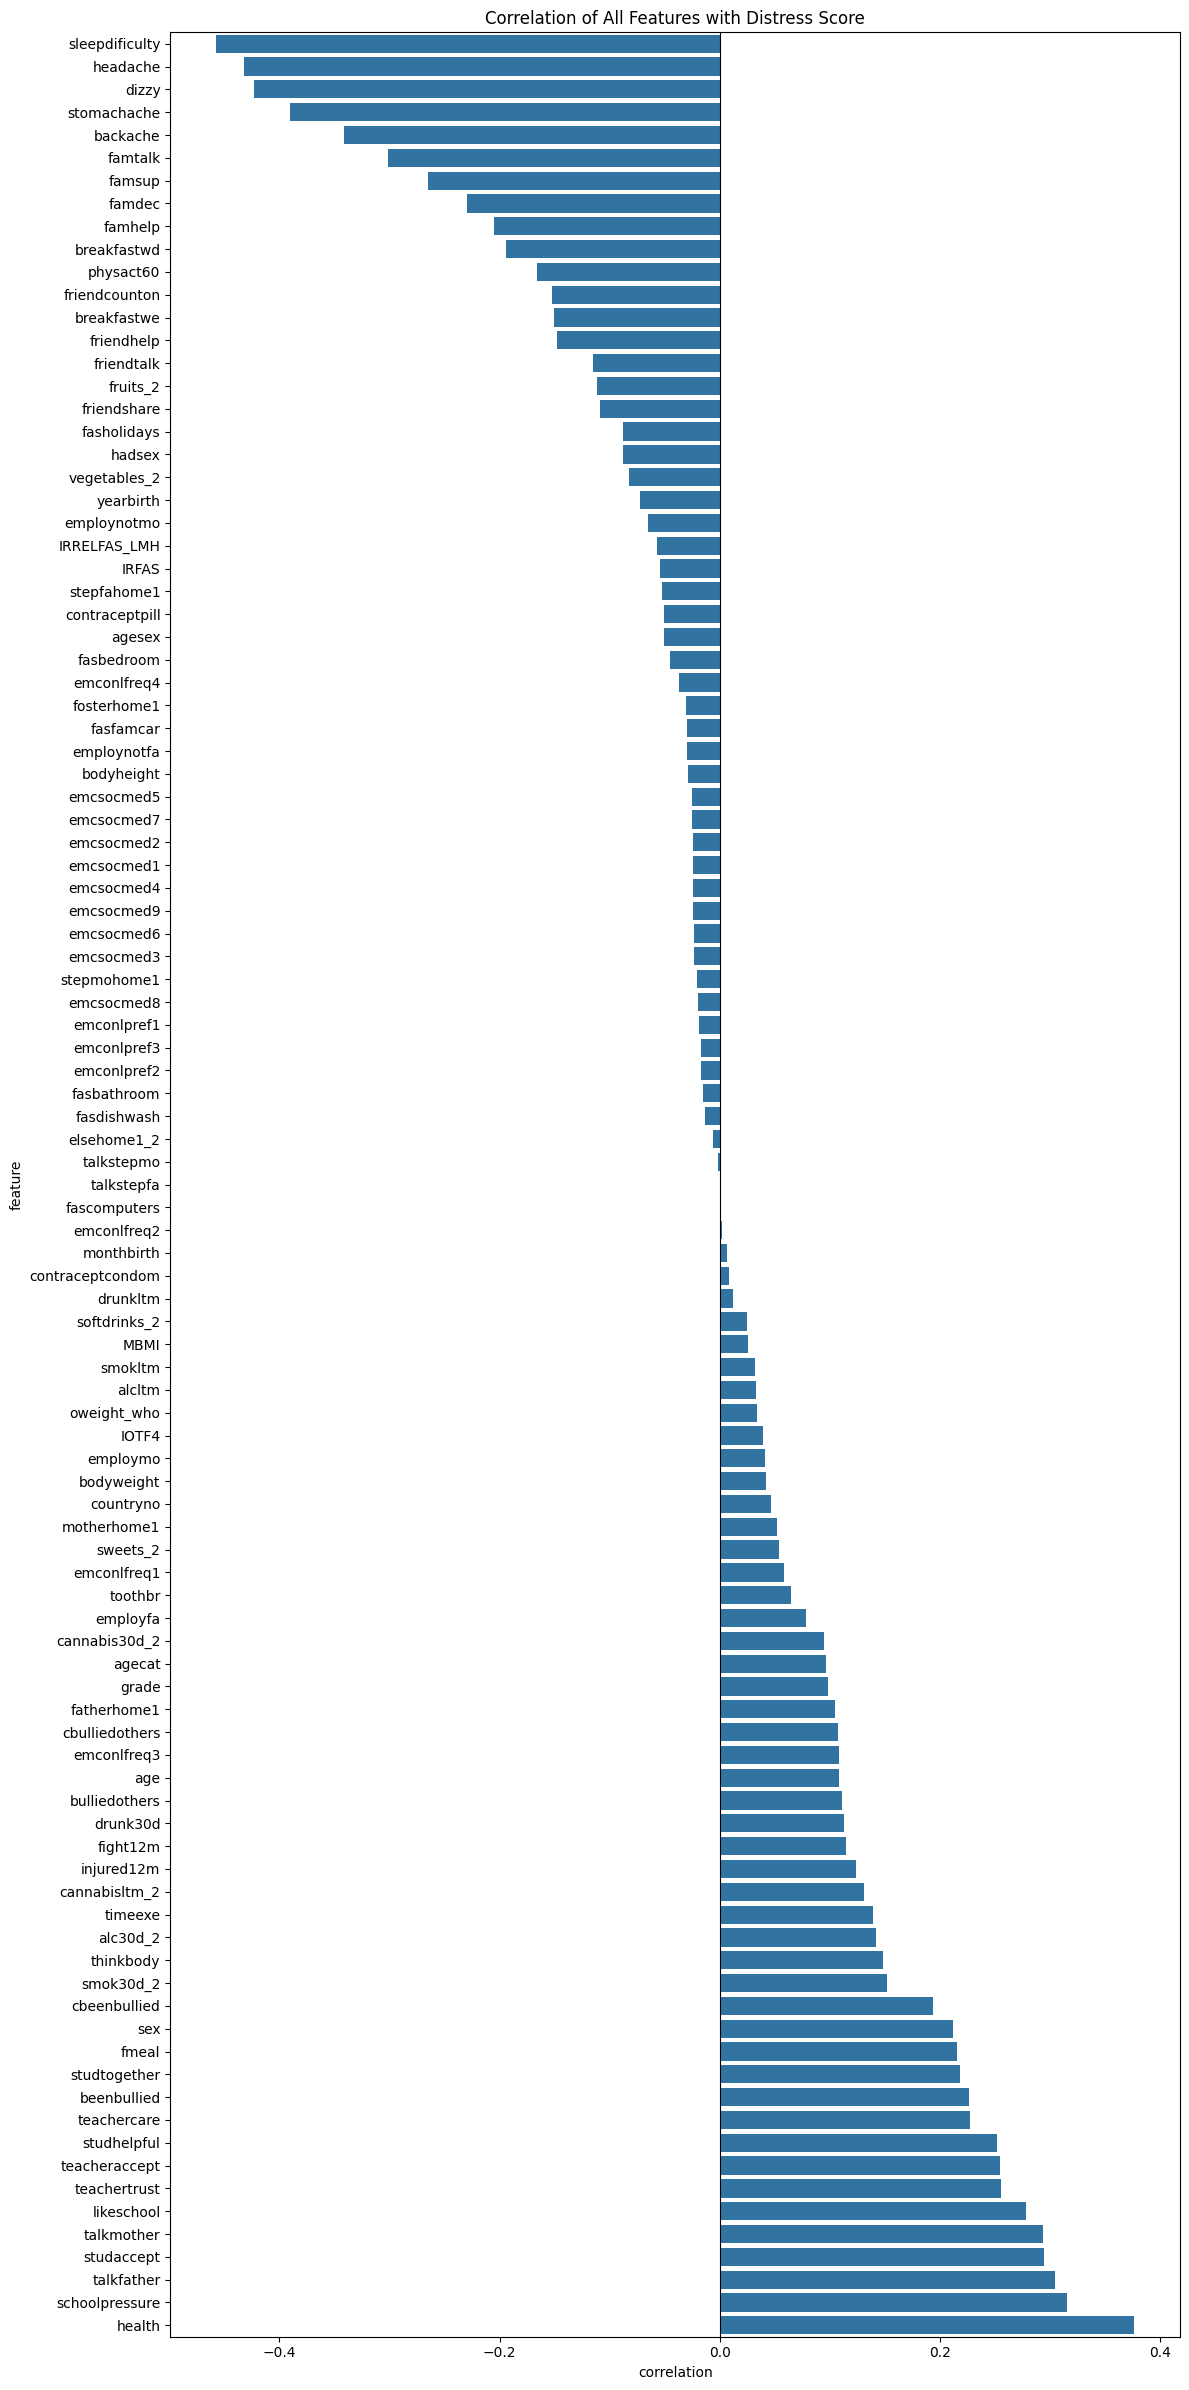

In [45]:
print_header("FEATURE CORRELATIONS")

corr_rows = []
for col in feature_cols:
    valid = working_df[[col, TARGET]].dropna()
    if len(valid) > 500:
        r = valid[col].corr(valid[TARGET])
        corr_rows.append({"feature": col, "correlation": r, "abs_corr": abs(r), "n": len(valid)})

corr_df = pd.DataFrame(corr_rows).sort_values("abs_corr", ascending=False)
print(corr_df.to_string(index=False))

plt.figure(figsize=(12, 24))
sns.barplot(data=corr_df.sort_values("correlation"), x="correlation", y="feature")
plt.title("Correlation of All Features with Distress Score")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

In [46]:
print_header("DEFINE MODELS")

elasticnet_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("model",   ElasticNetCV(
        cv=5,
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
        n_alphas=100,
        max_iter=100000,
        random_state=42
    ))
])

rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model",   RandomForestRegressor(
        n_estimators=500,
        max_depth=15,
        min_samples_leaf=20,
        max_features="sqrt",
        n_jobs=-1,
        random_state=42,
    ))
])

print("ElasticNet pipeline ready.")
print("Random Forest pipeline ready.")


DEFINE MODELS
ElasticNet pipeline ready.
Random Forest pipeline ready.


In [47]:
print_header("HYPERPARAMETER TUNING")

X_all      = working_df[feature_cols].copy()
y_all      = working_df[TARGET].copy()
strata_all = working_df["strata"].copy()

for col in X_all.columns:
    X_all[col] = pd.to_numeric(X_all[col], errors="coerce")

drop_cols = X_all.columns[X_all.isnull().mean() > 0.95].tolist()
if drop_cols:
    print(f"Dropping {len(drop_cols)} columns (>95% missing): {drop_cols}")
    X_all = X_all.drop(columns=drop_cols)
    feature_cols = [c for c in feature_cols if c not in drop_cols]
    print(f"Features remaining: {len(feature_cols)}")

print(f"X_all shape before imputation: {X_all.shape}")

imputer_tune = SimpleImputer(strategy="median")
X_imputed = imputer_tune.fit_transform(X_all)
print(f"X_imputed shape after imputation: {X_imputed.shape}")

X_all_imputed = pd.DataFrame(X_imputed, columns=feature_cols, index=X_all.index)

param_dist = {
    "n_estimators":     [300, 500, 800],
    "max_depth":        [10, 15, 20, 25, None],
    "min_samples_split": [5, 10, 20],
    "min_samples_leaf":  [5, 10, 20, 50],
    "max_features":      ["sqrt", "log2", 0.3, 0.5],
}

rscv = RandomizedSearchCV(
    RandomForestRegressor(n_jobs=-1, random_state=42),
    param_distributions=param_dist,
    n_iter=40,
    cv=3,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

rscv.fit(X_all_imputed, y_all)

print(f"\nBest CV R2: {rscv.best_score_:.4f}")
print("Best params:")
for k, v in rscv.best_params_.items():
    print(f"  {k}: {v}")

best_rf_params = rscv.best_params_.copy()
best_rf_params["n_jobs"] = -1
best_rf_params["random_state"] = 42

tuned_rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model",   RandomForestRegressor(**best_rf_params))
])
print("\nTuned RF pipeline ready.")


HYPERPARAMETER TUNING
Dropping 5 columns (>95% missing): ['region', 'countryborn', 'countrybornmo', 'countrybornfa', 'MBMI']
Features remaining: 100
X_all shape before imputation: (150867, 100)
X_imputed shape after imputation: (150867, 100)
Fitting 3 folds for each of 40 candidates, totalling 120 fits

Best CV R2: 0.4645
Best params:
  n_estimators: 800
  min_samples_split: 5
  min_samples_leaf: 5
  max_features: 0.5
  max_depth: None

Tuned RF pipeline ready.


In [48]:
print_header("REPEATED OOS VALIDATIONS")

models = {
    "ElasticNet":   elasticnet_pipeline,
    "RandomForest": tuned_rf_pipeline,
}

all_oos_results = []
rf_importances = []

for model_name, base_model in models.items():
    print(f"\n--- {model_name} ---")
    for run_id, seed in enumerate(RANDOM_SEEDS[:N_OOS_RUNS], start=1):
        X_train, X_test, y_train, y_test, _, _ = train_test_split(
            X_all, y_all, strata_all,
            test_size=TEST_SIZE, random_state=seed, stratify=strata_all
        )

        m = clone(base_model)
        m.fit(X_train, y_train)

        y_pred_train = m.predict(X_train)
        y_pred_test  = m.predict(X_test)

        row = {
            "model":      model_name,
            "run":        run_id,
            "seed":       seed,
            "train_r2":   r2_score(y_train, y_pred_train),
            "test_r2":    r2_score(y_test, y_pred_test),
            "train_rmse": rmse(y_train, y_pred_train),
            "test_rmse":  rmse(y_test, y_pred_test),
            "train_mae":  mean_absolute_error(y_train, y_pred_train),
            "test_mae":   mean_absolute_error(y_test, y_pred_test),
        }
        all_oos_results.append(row)

        if model_name == "RandomForest":
            imp = m.named_steps["model"].feature_importances_
            rf_importances.append(pd.DataFrame({
                "run": run_id, "feature": feature_cols, "importance": imp
            }))

        print(f"  Run {run_id}: train_r2={row['train_r2']:.4f}, test_r2={row['test_r2']:.4f}, test_rmse={row['test_rmse']:.2f}")

oos_df = pd.DataFrame(all_oos_results)


5 REPEATED OOS VALIDATIONS

--- ElasticNet ---
  Run 1: train_r2=0.5128, test_r2=0.5103, test_rmse=15.32
  Run 2: train_r2=0.5138, test_r2=0.5062, test_rmse=15.34
  Run 3: train_r2=0.5115, test_r2=0.5152, test_rmse=15.24
  Run 4: train_r2=0.5100, test_r2=0.5213, test_rmse=15.16
  Run 5: train_r2=0.5139, test_r2=0.5055, test_rmse=15.31

--- RandomForest ---
  Run 1: train_r2=0.8061, test_r2=0.5157, test_rmse=15.23
  Run 2: train_r2=0.8065, test_r2=0.5089, test_rmse=15.30
  Run 3: train_r2=0.8055, test_r2=0.5212, test_rmse=15.14
  Run 4: train_r2=0.8051, test_r2=0.5243, test_rmse=15.11
  Run 5: train_r2=0.8067, test_r2=0.5082, test_rmse=15.27



MODEL COMPARISON
              mean_test_r2  std_test_r2  mean_test_rmse  std_test_rmse  mean_test_mae  std_test_mae  mean_train_r2
model                                                                                                             
ElasticNet          0.5117       0.0066         15.2741         0.0736        12.0147        0.0447         0.5124
RandomForest        0.5157       0.0072         15.2116         0.0804        11.9729        0.0502         0.8060

R2 improvement:   0.5117 -> 0.5157 (+0.0040)
RMSE improvement: 15.27 -> 15.21 (-0.06)


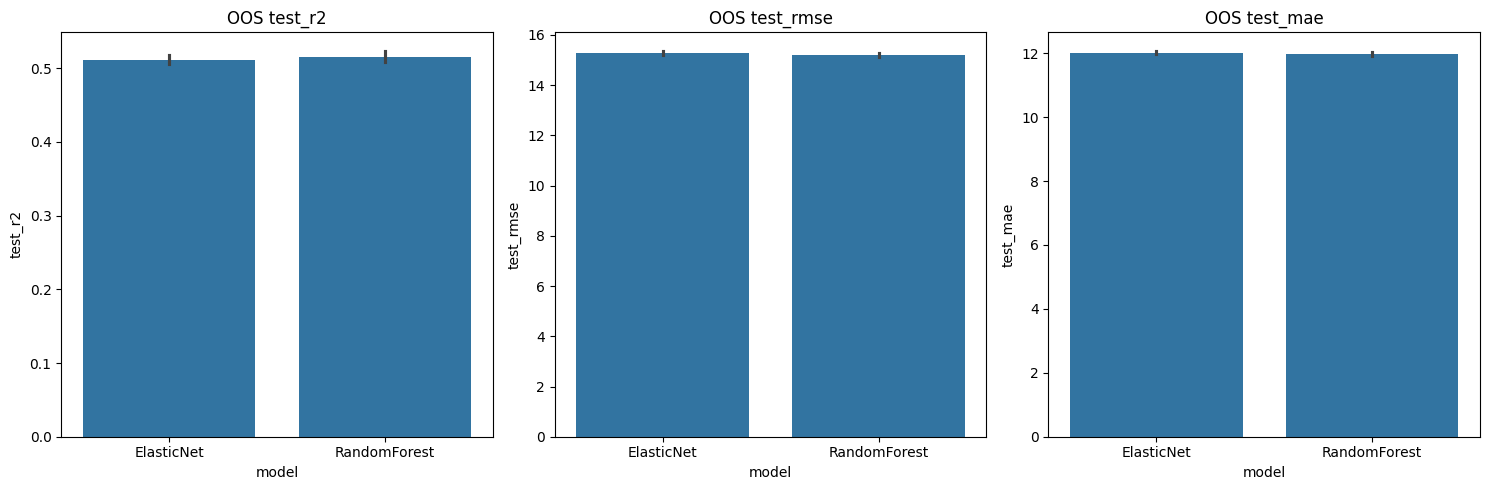

In [49]:
print_header("MODEL COMPARISON")

comparison = (
    oos_df.groupby("model")
    .agg(
        mean_test_r2   = ("test_r2",   "mean"),
        std_test_r2    = ("test_r2",   "std"),
        mean_test_rmse = ("test_rmse", "mean"),
        std_test_rmse  = ("test_rmse", "std"),
        mean_test_mae  = ("test_mae",  "mean"),
        std_test_mae   = ("test_mae",  "std"),
        mean_train_r2  = ("train_r2",  "mean"),
    )
    .round(4)
)
print(comparison.to_string())

en_r2   = comparison.loc["ElasticNet",   "mean_test_r2"]
rf_r2   = comparison.loc["RandomForest", "mean_test_r2"]
en_rmse = comparison.loc["ElasticNet",   "mean_test_rmse"]
rf_rmse = comparison.loc["RandomForest", "mean_test_rmse"]

print(f"\nR2 improvement:   {en_r2:.4f} -> {rf_r2:.4f} (+{rf_r2 - en_r2:.4f})")
print(f"RMSE improvement: {en_rmse:.2f} -> {rf_rmse:.2f} ({rf_rmse - en_rmse:.2f})")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, metric in enumerate(["test_r2", "test_rmse", "test_mae"]):
    sns.barplot(data=oos_df, x="model", y=metric, ax=axes[i], errorbar="sd")
    axes[i].set_title(f"OOS {metric}")
plt.tight_layout()
plt.show()


FEATURE IMPORTANCE
         feature  mean_importance  std_importance
  sleepdificulty         0.169018        0.001354
        headache         0.100861        0.000928
           dizzy         0.067685        0.001218
          health         0.051253        0.001254
     stomachache         0.044214        0.001144
      talkfather         0.033358        0.001569
  schoolpressure         0.033097        0.000472
         famtalk         0.026472        0.001398
        backache         0.020195        0.000294
       countryno         0.017861        0.000174
          famsup         0.016107        0.000442
      emcsocmed8         0.015890        0.000864
      talkmother         0.015719        0.000927
      studaccept         0.015001        0.000328
             age         0.014841        0.000151
      bodyheight         0.013533        0.000060
      likeschool         0.013293        0.000593
      bodyweight         0.012959        0.000160
       physact60         0.011

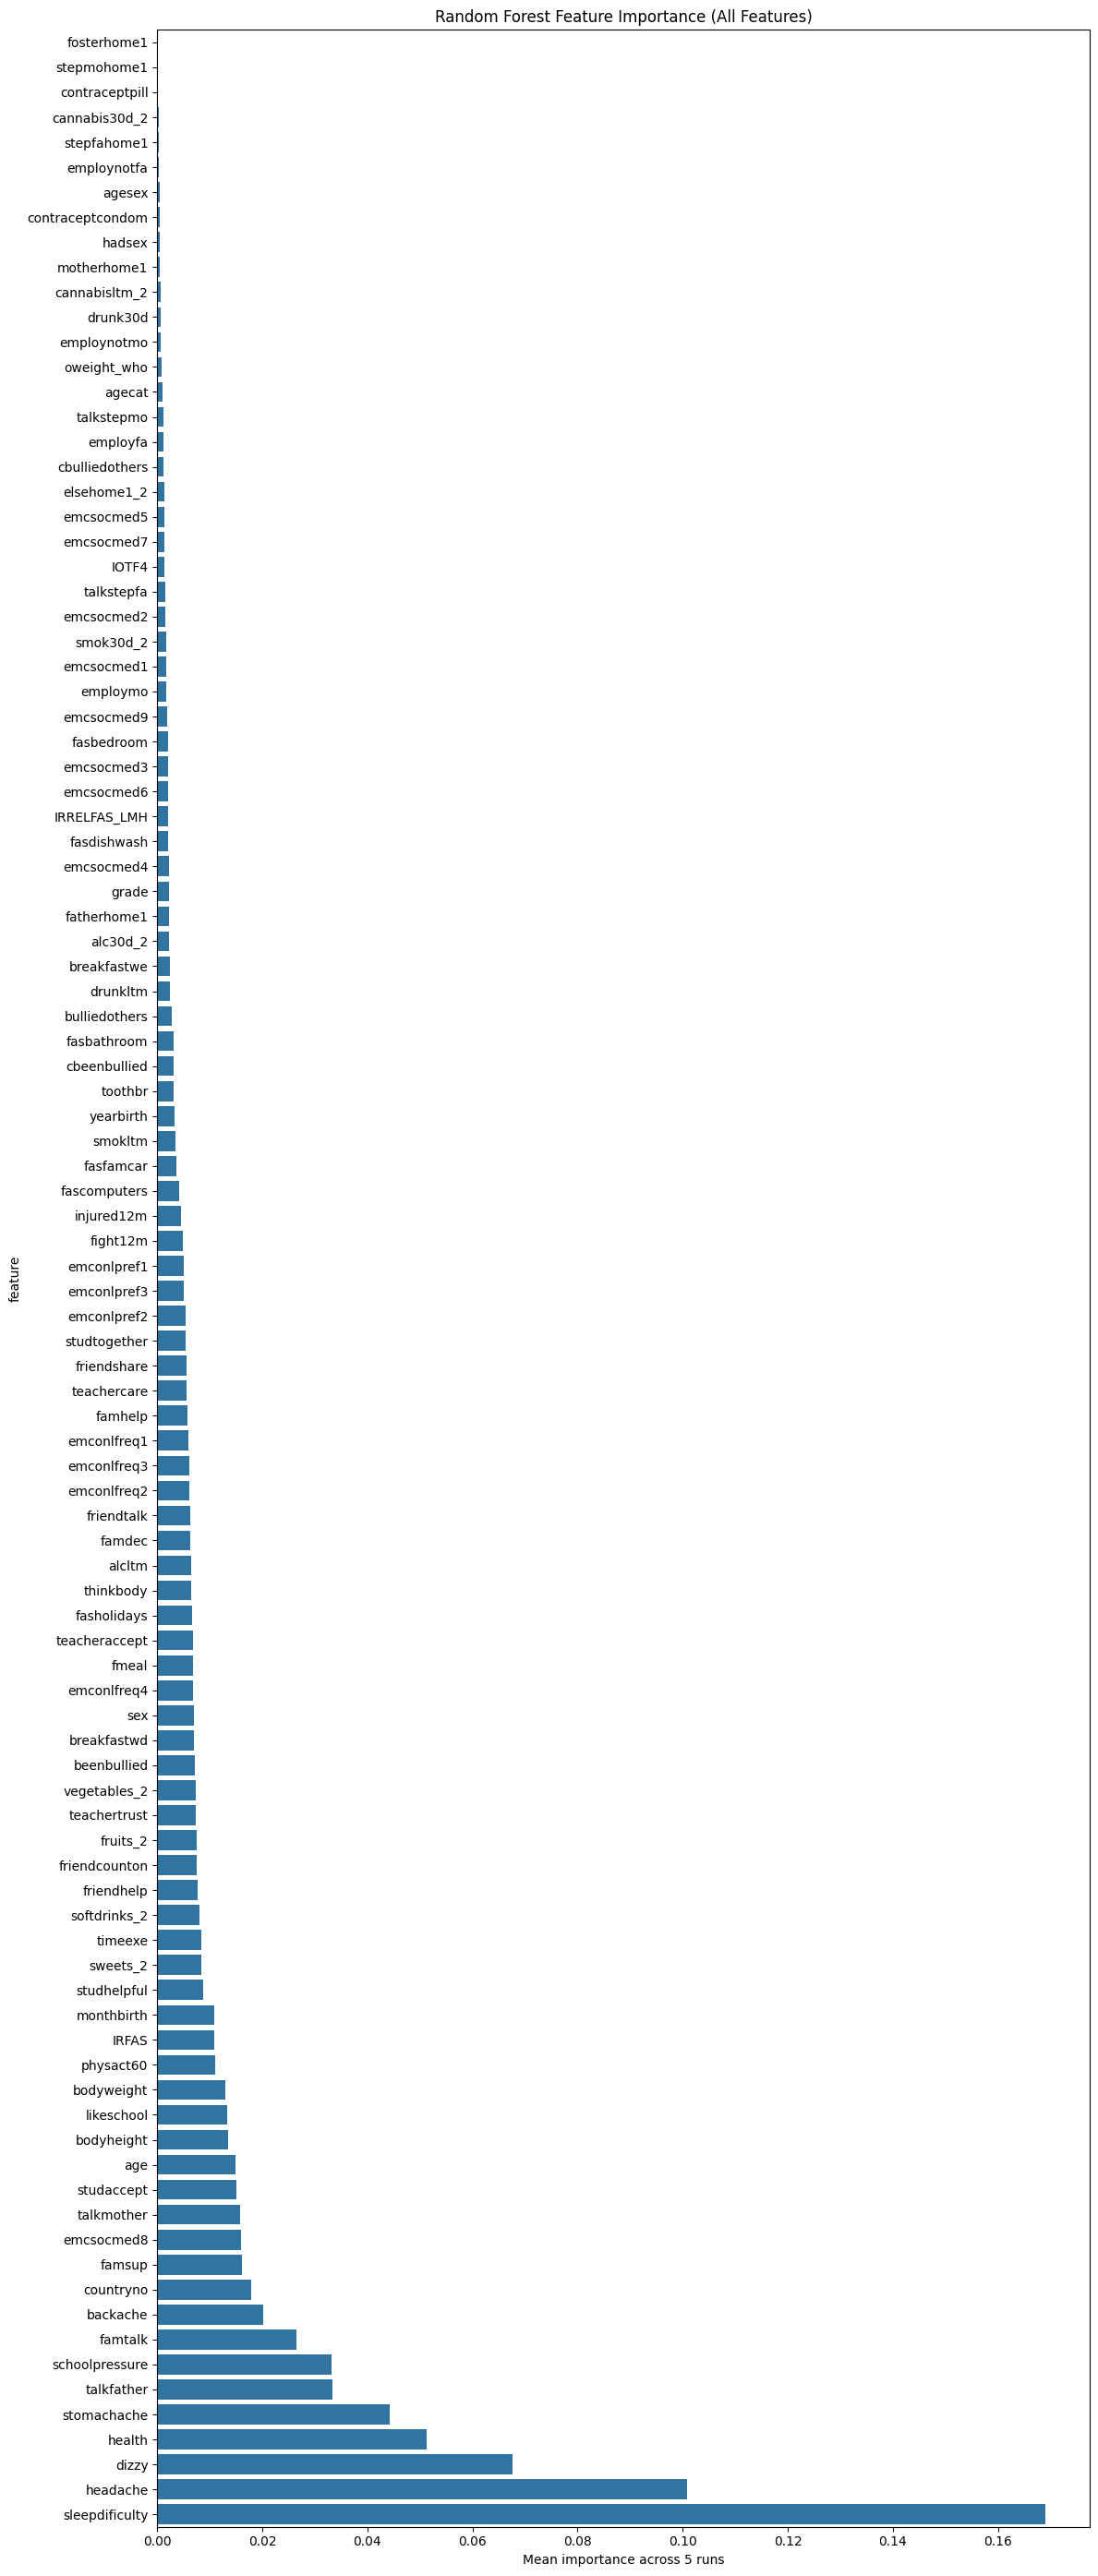

In [50]:
print_header("FEATURE IMPORTANCE")

imp_df = pd.concat(rf_importances, ignore_index=True)
imp_summary = (
    imp_df.groupby("feature")
    .agg(
        mean_importance = ("importance", "mean"),
        std_importance  = ("importance", "std"),
    )
    .sort_values("mean_importance", ascending=False)
    .reset_index()
)

print(imp_summary.to_string(index=False))

plt.figure(figsize=(12, 28))
sns.barplot(
    data=imp_summary.sort_values("mean_importance", ascending=True),
    x="mean_importance", y="feature"
)
plt.title("Random Forest Feature Importance (All Features)")
plt.xlabel("Mean importance across 5 runs")
plt.tight_layout()
plt.show()

In [51]:
print_header("FINAL MODEL ON FULL SAMPLE")

final_rf = clone(tuned_rf_pipeline)
final_rf.fit(X_all, y_all)

full_pred = final_rf.predict(X_all)
diagnostic_df = working_df.copy()
diagnostic_df["predicted_distress"] = full_pred
diagnostic_df["residual"]           = full_pred - diagnostic_df[TARGET]
diagnostic_df["abs_error"]          = diagnostic_df["residual"].abs()

in_sample_r2 = r2_score(diagnostic_df[TARGET], full_pred)
rf_mean_oos = oos_df[oos_df["model"] == "RandomForest"]["test_r2"].mean()
print(f"In-sample R2: {in_sample_r2:.4f}")
print(f"Mean OOS R2:  {rf_mean_oos:.4f}")
print(f"Overfit gap:  {in_sample_r2 - rf_mean_oos:.4f}")


FINAL MODEL ON FULL SAMPLE
In-sample R2: 0.8068
Mean OOS R2:  0.5157
Overfit gap:  0.2912


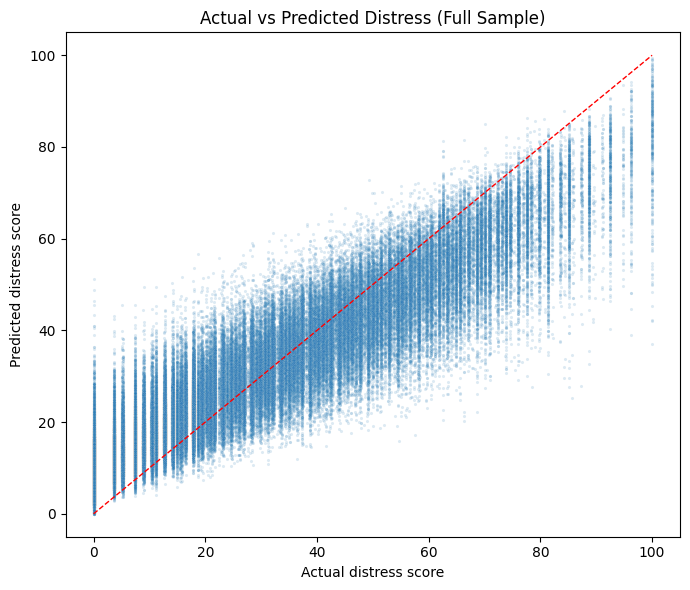

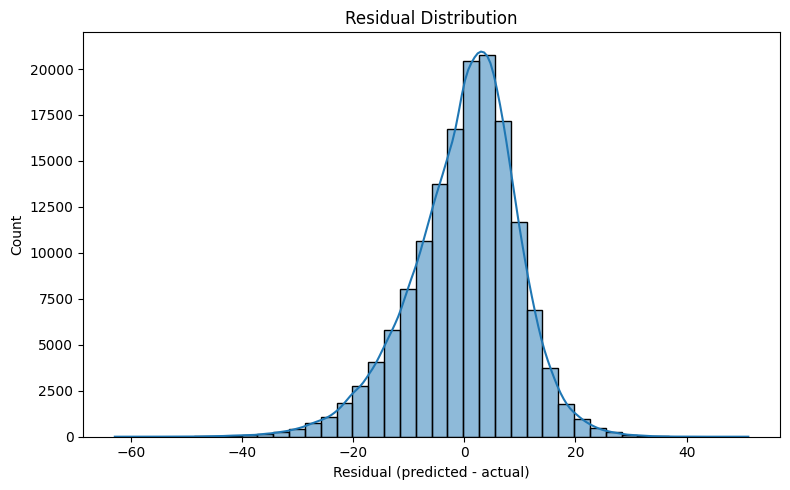

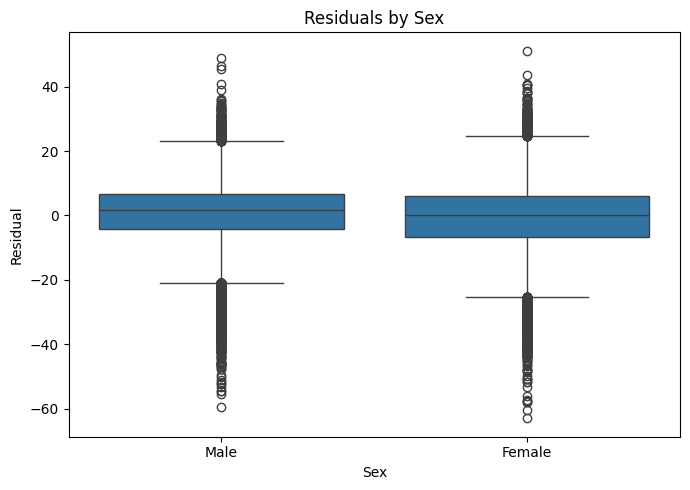

In [52]:
plt.figure(figsize=(7, 6))
sns.scatterplot(
    x=diagnostic_df[TARGET],
    y=diagnostic_df["predicted_distress"],
    alpha=0.15, s=5
)
lo = min(diagnostic_df[TARGET].min(), diagnostic_df["predicted_distress"].min())
hi = max(diagnostic_df[TARGET].max(), diagnostic_df["predicted_distress"].max())
plt.plot([lo, hi], [lo, hi], linestyle="--", color="red", linewidth=1)
plt.title("Actual vs Predicted Distress (Full Sample)")
plt.xlabel("Actual distress score")
plt.ylabel("Predicted distress score")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(diagnostic_df["residual"], bins=40, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residual (predicted - actual)")
plt.tight_layout()
plt.show()

if "sex" in diagnostic_df.columns:
    plt.figure(figsize=(7, 5))
    sns.boxplot(
        data=diagnostic_df,
        x=diagnostic_df["sex"].map({1: "Male", 2: "Female"}),
        y="residual"
    )
    plt.title("Residuals by Sex")
    plt.xlabel("Sex")
    plt.ylabel("Residual")
    plt.tight_layout()
    plt.show()

In [53]:
print_header("SAVE OUTPUTS")

oos_df.to_csv("rf_oos_results.csv", index=False)
comparison.to_csv("rf_vs_elasticnet_comparison.csv")
imp_summary.to_csv("rf_feature_importance.csv", index=False)
diagnostic_df.to_csv("rf_final_predictions.csv", index=False)

print("Saved:")
for f in [
    "rf_oos_results.csv",
    "rf_vs_elasticnet_comparison.csv",
    "rf_feature_importance.csv",
    "rf_final_predictions.csv",
]:
    print(" -", f)


SAVE OUTPUTS
Saved:
 - rf_oos_results.csv
 - rf_vs_elasticnet_comparison.csv
 - rf_feature_importance.csv
 - rf_final_predictions.csv


In [54]:
print_header("SUMMARY")

rf_oos = oos_df[oos_df["model"] == "RandomForest"]
en_oos = oos_df[oos_df["model"] == "ElasticNet"]

print("Random Forest")
print(f"  Mean OOS R2:   {rf_oos['test_r2'].mean():.4f} +/- {rf_oos['test_r2'].std():.4f}")
print(f"  Mean OOS RMSE: {rf_oos['test_rmse'].mean():.2f} +/- {rf_oos['test_rmse'].std():.2f}")
print(f"  Mean OOS MAE:  {rf_oos['test_mae'].mean():.2f} +/- {rf_oos['test_mae'].std():.2f}")

print("\nElasticNet")
print(f"  Mean OOS R2:   {en_oos['test_r2'].mean():.4f} +/- {en_oos['test_r2'].std():.4f}")
print(f"  Mean OOS RMSE: {en_oos['test_rmse'].mean():.2f} +/- {en_oos['test_rmse'].std():.2f}")
print(f"  Mean OOS MAE:  {en_oos['test_mae'].mean():.2f} +/- {en_oos['test_mae'].std():.2f}")

print(f"\nR2:   {en_oos['test_r2'].mean():.4f} -> {rf_oos['test_r2'].mean():.4f} (+{rf_oos['test_r2'].mean() - en_oos['test_r2'].mean():.4f})")
print(f"RMSE: {en_oos['test_rmse'].mean():.2f} -> {rf_oos['test_rmse'].mean():.2f} ({rf_oos['test_rmse'].mean() - en_oos['test_rmse'].mean():.2f})")

print("\nAll features by importance:")
print(imp_summary.to_string(index=False))


SUMMARY
Random Forest
  Mean OOS R2:   0.5157 +/- 0.0072
  Mean OOS RMSE: 15.21 +/- 0.08
  Mean OOS MAE:  11.97 +/- 0.05

ElasticNet
  Mean OOS R2:   0.5117 +/- 0.0066
  Mean OOS RMSE: 15.27 +/- 0.07
  Mean OOS MAE:  12.01 +/- 0.04

R2:   0.5117 -> 0.5157 (+0.0040)
RMSE: 15.27 -> 15.21 (-0.06)

All features by importance:
         feature  mean_importance  std_importance
  sleepdificulty         0.169018        0.001354
        headache         0.100861        0.000928
           dizzy         0.067685        0.001218
          health         0.051253        0.001254
     stomachache         0.044214        0.001144
      talkfather         0.033358        0.001569
  schoolpressure         0.033097        0.000472
         famtalk         0.026472        0.001398
        backache         0.020195        0.000294
       countryno         0.017861        0.000174
          famsup         0.016107        0.000442
      emcsocmed8         0.015890        0.000864
      talkmother         